# Reranker를 활용한 RAG 챗봇 고도화

## 실습 목표
---
RAG 과정에서 Reranker를 활용하여 챗봇의 성능을 높일 수 있는 방법을 학습합니다.

## 실습 목차
---

1. **Reranker 구현:** LangGraph 기반 챗봇에 Reranker를 구현하고, Graph 구조를 변경합니다.

2. **챗봇 고도화:** Reranker의 파라미터를 조정하며 최적의 구성을 탐색합니다.

## 0. 환경 설정
- 필요한 라이브러리를 불러옵니다.

In [1]:
import os
from typing import List

from dotenv import load_dotenv
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_chroma import Chroma
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_core.output_parsers import JsonOutputParser, StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import OllamaEmbeddings
from langchain_openai import ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, START, StateGraph
from IPython.display import Image, display
from typing_extensions import TypedDict

load_dotenv()

/var/folders/px/v7_qzrl907d919ql0sn3f74r0000gn/T/ipykernel_4168/2923677229.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.cross_encoders import HuggingFaceCrossEncoder


True

ChatGPT API(`.env`의 `MODEL_NAME`, 예: gpt-4o-mini)를 챗봇용으로, Ollama의 `qwen3-embedding:0.6b` 모델(이미 실습1 폴더에서 설치함)을 임베딩용으로 불러옵니다.

* `llm` : 검색된 문서를 바탕으로 최종 답변을 생성하는 모델
* `route_llm` : RAG 사용 여부를 JSON으로 판단하는 라우팅 전용 모델 (`llm`에 JSON 출력 모드를 추가한 것)

In [2]:
llm = ChatOpenAI(
    model=os.environ["MODEL_NAME"],
    base_url=os.environ["BASE_URL"],
    api_key=os.environ["OPENAI_API_KEY"],
    temperature=0,
)
# llm.bind(...)로 JSON 강제 출력 옵션을 추가해 route_llm을 만듭니다. (동일 모델, 다른 출력 형식)
route_llm = llm.bind(response_format={"type": "json_object"})

data_dir = "data"

pdf_data_name = "RE177_2023년 국내외 인공지능 산업 동향 연구_2장.pdf"

인공지능 산업 동향 연구 문서를 불러옵니다.
- 출처: 소프트웨어정책연구소 (SRPI) 2023년 국내외 인공지능 산업 동향 연구 보고서 (일부 발췌)
  - 본 과정에서는 전체 보고서 중 제2장 인공지능 산업 현황 및 전망 구간만 발췌하여 사용합니다.
  - https://spri.kr/posts/view/23728?code=research&study_type=&board_type=&flg=#none

In [3]:
embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")

# 시장 조사 문건을 불러옵니다.
doc_path = os.path.join(data_dir, pdf_data_name)
loader = PyPDFLoader(doc_path)
docs = loader.load()

# Split text
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=10)
docs = text_splitter.split_documents(docs)

len_docs = [len(doc.page_content) for doc in docs]
print(f"총 Document 개수: {len(docs)}")
print(f"Document 별 길이: {len_docs}")
print(f"Document 별 길이 평균: {sum(len_docs) / len(len_docs)}")

총 Document 개수: 49
Document 별 길이: [440, 230, 226, 351, 5, 499, 243, 77, 432, 430, 322, 499, 116, 6, 497, 496, 192, 6, 497, 496, 394, 6, 498, 411, 249, 6, 496, 498, 16, 328, 473, 198, 477, 43, 495, 172, 6, 499, 494, 44, 279, 495, 21, 102, 494, 181, 467, 297, 314]
Document 별 길이 평균: 296.18367346938777


Reranker 객체를 정의합니다.

In [4]:
top_n_reranked_docs = 3
# 모델 초기화
cross_encoder = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-v2-m3")

# 상위 3개의 문서를 선택하는 Reranker
reranker = CrossEncoderReranker(model=cross_encoder, top_n=top_n_reranked_docs)

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

`OllamaEmbeddings`를 활용해 벡터로 변환하고, Chroma DB에 저장합니다.
- 변환 과정은 약 1분 정도 소요됩니다.

In [5]:
%%time
persist_dir = "./vectorstore/chroma"

# 이미 임베딩된 벡터스토어가 있으면 그대로 불러오고, 없으면 새로 임베딩해서 저장합니다.
if os.path.exists(persist_dir):
    vectorstore = Chroma(embedding_function=embeddings, persist_directory=persist_dir)
    print(f"[vectorstore] 기존 벡터스토어 로드 완료 (저장된 벡터 수: {vectorstore._collection.count()})")
else:
    vectorstore = Chroma.from_documents(
        docs,
        embedding=embeddings,
        persist_directory=persist_dir,
    )
    print(f"[vectorstore] 새로 임베딩 완료 (저장된 벡터 수: {vectorstore._collection.count()})")

# Reranker를 통해 한번 더 정렬할 예정이므로, 탐색할 k값을 top_n의 5배로 설정합니다.
db_retriever = vectorstore.as_retriever(
    search_kwargs={"k": top_n_reranked_docs * 5}
)

[vectorstore] 새로 임베딩 완료 (저장된 벡터 수: 49)
CPU times: user 85.9 ms, sys: 33 ms, total: 119 ms
Wall time: 6.07 s


## 1. 각 기능 별 그래프 노드 정의

- PDF 문서 기반 RAG 챗봇을 정의합니다.

In [6]:
class State(TypedDict):
    # 그래프 상태의 속성을 정의합니다.
    # 질문, LLM이 생성한 텍스트, 검색된 데이터를 저장합니다.
    question: str
    generation: str
    data: str

In [7]:
def answer(state: State) -> State:
    # 데이터를 쿼리하지 않고 답변을 바로 생성합니다.
    print("[plain_answer] RAG 없이 답변 생성 중...")
    question = state["question"]

    return {"question": question, "generation": llm.invoke(question).content}


def rerank(query: str, _docs: List[Document]) -> List[Document]:
    # 1차로 검색된 문서 목록을 질문과의 연관성 기준으로 재정렬해 상위 top_n개만 남깁니다.
    reranked_docs = reranker.compress_documents(_docs, query)
    return reranked_docs


def retrieval(state: State):
    """
    Vector DB에서 1차 검색 후, Reranker로 재정렬한 데이터를 반환합니다.

    Args:
        state (dict): 현재 그래프 상태

    Returns:
        state (dict): 검색된 데이터를 포함한 새로운 State
    """
    print("[rag] 문서 검색 중...")
    question = state["question"]

    # question을 db_retriever에 전달하여 문서를 1차로 검색하고, rerank 함수를 통해 정렬합니다.
    # 이후 상위 top_n개의 문서를 반환합니다.
    retrieval_chain = (
        db_retriever
        | (lambda _retrieved_docs: rerank(question, _retrieved_docs))
    )
    data = retrieval_chain.invoke(question)
    print(f"[rag] 1차 검색 {top_n_reranked_docs * 5}개 → rerank 이후 {len(data)}개")

    return {"question": question, "data": data}

`rerank` 함수가 어떤 입력을 받아 어떤 출력을 내는지, reranking 전후 문서 개수와 순서가 어떻게 바뀌는지 확인해봅시다.

In [12]:
sample_query = "인공지능 산업 현황 및 전망에 대해 알려줘"

# rerank 이전: db_retriever가 1차로 회수한 top_n*5개 문서
sample_pre_docs = db_retriever.invoke(sample_query)
print(f"[rerank 이전] {len(sample_pre_docs)}개 문서")
for doc in sample_pre_docs:
    print("="*20)
    print("1. ", doc.page_content[:100])

# rerank 이후: 질문과의 연관성 기준으로 재정렬된 상위 top_n개 문서
sample_reranked_docs = rerank(sample_query, sample_pre_docs)
print(f"[rerank 이후] {len(sample_reranked_docs)}개 문서")
print(f"[rerank 이후] 1위 문서 미리보기: {sample_reranked_docs[0].page_content[:100]}")

[rerank 이전] 15개 문서
1.  - 4 -
제2장인공지능산업현황및전망제1절AI 산업 현황 1.전 세계 AI 현황 및 수준2023년 4월, 미국 스탠포드 대학의 HAI는 2023년 AI 분야의 국제적인 수준을 비교
1.  출처: Stanford University, Artificial Intelligence Index Report 2023, 2023;이번 2023년 AI 인덱스 보고서는 글로벌 AI
1.  - 9 -
3.생성 AI 산업 동향   (1) 구글과 마이크로소프트, 개발자 컨퍼런스에서 생성 AI 구상 발표2022년 11월 오픈AI(OpenAI)가 챗GPT를 시장에 공개한 이
1.  츨처: McKinsey, The economic potential of generative AI: The next productivity frontier, 2023.06.14.또한
1.  - 15 -
제2절인공지능 산업 전망 1.전 세계 AI 시장 전망  (1) 스태티스타, AI 시장 전망11) 글로벌 시장 조사기관인 스태티스타(Statista)는 2023년 10월
1.  출처: Stanford University, Artificial Intelligence Index Report 2023, 2023;
1) Stanford University, Ar
1.  이전에는 자동화 가능성이 가장 낮았던 의사결정과 협업과 관련된 업무를 중심으로 자동화를 진전시킬 것이며, 교육과 IT 직종 등에서 생성 AI에 의한 업무 전환이 가속화 추세을 보였
1.  2.전 세계 생성 AI 시장 예측13) 2023년 6월 블룸버그 인텔리전스는 챗GPT와 구글 바드 등 소비자용 AI 도구의 출시에 힘입어 생성 AI 시장이 2022년 400억 달러
1.  2027년까지 35.8%의 연평균 성장률이 예상됨ㅇ 분석, 비즈니스 인텔리전스, 데이터 관리와 통합을 포함하는 AI SIS는 기존 소프12) https://www.marketsan
1.  - 18 -
핵심적인 부분이 될 것으로 전망되었다.최대 성

In [13]:
def answer_with_retrieved_data(state: State):
    """
    Reranker로 재정렬된 문서를 바탕으로 답변을 생성합니다.

    Args:
        state (dict): 현재 그래프 상태

    Returns:
        state (dict): LLM의 답변을 포함한 새로운 State
    """
    print("[answer_with_retrieval] 검색된 문서를 바탕으로 답변 생성 중...")
    question = state["question"]
    data = state["data"]

    print(f"[answer_with_retrieval] rerank 이후 top {len(data)} 문서:")
    for i, doc in enumerate(data):
        print(f"  [{i}] {doc.page_content[:80]}")

    # Document 객체가 아니라 순수 텍스트만 추출해서 context로 사용합니다.
    context_text = "\n\n".join(doc.page_content for doc in data)

    messages_with_contexts = [
        ("system", "사용자가 입력하는 정보를 바탕으로 질문에 답하세요."),
        ("human", "정보: {context}.\n{question}."),
    ]
    prompt_with_context = ChatPromptTemplate.from_messages(messages_with_contexts)

    qa_chain = prompt_with_context | llm | StrOutputParser()
    generation = qa_chain.invoke({"context": context_text, "question": question})
    return {"question": question, "data": data, "generation": generation}

**라우팅 전문가 페르소나**를 적용한 체인을 통해 원하는 로직을 선택할 수 있도록 설정해봅시다. 

In [14]:
# 시스템 메시지에 사용 가능한 툴과 각 툴을 사용할 상황을 명시합니다.
# 수월한 선택을 위해 JSON 형식으로 출력하도록 프롬프트에 지정합니다.
route_system_message = """당신은 사용자의 질문에 RAG 사용 여부를 결정하는 전문가입니다.
인공지능 산업, 시장 동향, 기업 동향, 정책, 투자 등과 관련된 질문이라면 'rag'를 선택하고,
그렇지 않다면(일상 대화, 개인적 취향 등) 'plain_answer'를 선택하세요.

예시:
질문: "2022년 AI 투자 규모는?" -> {{"route": "rag"}}
질문: "챗GPT 관련 최근 동향은?" -> {{"route": "rag"}}
질문: "오늘 저녁 뭐 먹을까?" -> {{"route": "plain_answer"}}
질문: "너는 누구야?" -> {{"route": "plain_answer"}}

답변은 'route' 키 하나만 있는 JSON으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""
route_user_message = "{question}"
route_prompt = ChatPromptTemplate.from_messages(
    [("system", route_system_message), ("human", route_user_message)]
)

# route_llm(JSON 강제 출력 모드)을 사용해 라우팅 체인을 구성합니다.
router_chain = route_prompt | route_llm | JsonOutputParser()

다양한 질문에 대해 테스트 해보고, 그 결과를 확인해 봅시다.

In [15]:
print(router_chain.invoke({"question": "인공지능 산업 현황 및 전망에 대해 알려줘"}))
print(router_chain.invoke({"question": "오늘 저녁 뭐 먹을까?"}))

{'route': 'rag'}
{'route': 'plain_answer'}


대부분 잘 결정하는 것을 볼 수 있습니다.<br>
이 체인을 활용해서 고도화된 `init_answer` 함수를 정의합니다.

In [16]:
def init_answer(state: State) -> State:
    print("[init_answer] 질문 라우팅 중...")
    question = state["question"]
    route = router_chain.invoke({"question": question})["route"]
    print(f"[init_answer] 선택된 경로: {route}")
    return {"question": question, "generation": route}


def route_question(state: State) -> str:
    route = state["generation"]
    return route.lower().strip()

노드와 간선을 그래프에 추가합니다.

In [17]:
## 그래프 구성

workflow = StateGraph(State)

# 앞서 정의한 Node를 모두 추가합니다.
workflow.add_node("init_answer", init_answer)
workflow.add_node("rag", retrieval)
workflow.add_node("plain_answer", answer)
workflow.add_node("answer_with_retrieval", answer_with_retrieved_data)

# 시작지점을 정의합니다.
workflow.add_edge(START, "init_answer")

# 간선을 정의합니다. END는 종결 지점을 의미합니다.
workflow.add_edge("plain_answer", END)
workflow.add_edge("answer_with_retrieval", END)
workflow.add_edge("rag", "answer_with_retrieval")

# 조건부 간선을 정의합니다.
# init_answer 노드의 답변을 바탕으로 route_question 함수에서 rag 또는 plain_answer로 분기합니다.
workflow.add_conditional_edges(
    "init_answer",
    route_question,
    # 어떤 노드로 이동할지 mapping합니다. 없어도 무방하지만, Graph의 가독성을 높일 수 있습니다.
    {
        "rag": "rag",
        "plain_answer": "plain_answer",
    },
)

Node, Edge, 분기를 모두 구성했으니 이제 그래프를 컴파일 하고, 그 구조를 확인해 봅시다.

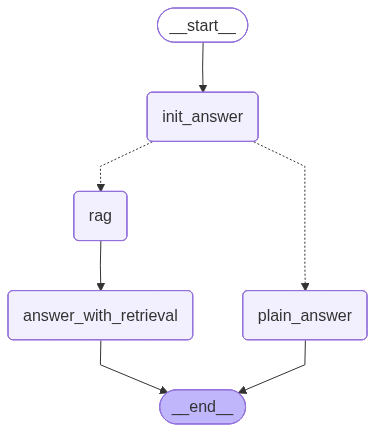

In [18]:
graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

이제 챗봇을 사용해봅시다.

**테스트 질문 예시**

- RAG 경로 (인공지능 산업 동향 연구 문서 활용)
  - 질문: "인공지능 산업 현황 및 전망에 대해 알려줘"
  - 질문: "구글·마이크로소프트·오픈AI·앤스로픽이 공동 설립한 AI 안전 협의기구의 이름은?"
- 일반 답변 경로 (데이터 무관)
  - 질문: "오늘 저녁 뭐 먹을까?"

답변 생성에는 평균 20~30초 정도 소요됩니다. 1분 넘게 답변이 생성되지 않을 경우 강제 종료 후 재시작 해주세요.

In [19]:
while True:
    question = input("질문을 입력해주세요 (종료를 원하시면 '종료'를 입력해주세요.): ")
    if question == "종료":
        break
    else:
        # graph.invoke 함수를 사용하여 그래프를 실행하고, 최종 결과를 반환합니다.
        response = graph.invoke({"question": question})
        print("Assistant: ", response["generation"])

[init_answer] 질문 라우팅 중...
[init_answer] 선택된 경로: plain_answer
[plain_answer] RAG 없이 답변 생성 중...
Assistant:  Hello! How can I assist you today?
[init_answer] 질문 라우팅 중...
[init_answer] 선택된 경로: rag
[rag] 문서 검색 중...
[rag] 1차 검색 15개 → rerank 이후 3개
[answer_with_retrieval] 검색된 문서를 바탕으로 답변 생성 중...
[answer_with_retrieval] rerank 이후 top 3 문서:
  [0] - 4 -
제2장인공지능산업현황및전망제1절AI 산업 현황 1.전 세계 AI 현황 및 수준2023년 4월, 미국 스탠포드 대학의 HAI는 2023
  [1] - 15 -
제2절인공지능 산업 전망 1.전 세계 AI 시장 전망  (1) 스태티스타, AI 시장 전망11) 글로벌 시장 조사기관인 스태티스타(
  [2] - 18 -
핵심적인 부분이 될 것으로 전망되었다.최대 성장 동인인 AI 모델 학습용 데이터 인프라 시장 규모는 2032년까지 2,470억 달러
Assistant:  인공지능(AI) 산업의 현황과 전망에 대한 정보는 다음과 같습니다.

### 1. AI 산업 현황
- **AI 인덱스 보고서**: 2023년 4월, 스탠포드 대학의 HAI는 AI 분야의 국제적인 수준을 비교 분석한 'AI 인덱스 보고서'를 발표했습니다. 이 보고서는 연구개발, 기술적 성과, 윤리, 경제, 교육, AI 정책 및 거버넌스, 다양성, 여론 등 다양한 측면에서 AI 발전의 속도를 측정하고 평가했습니다.
- **국가 AI 전략**: HAI는 전 세계 국가의 AI 전략 수립 현황을 조사하여, 공표된 국가(Released), 개발 중인 국가(In Development), 미공표 국가(Not Released)로 구분했습니다. 2022년에는 이탈리아와 대만이 새로운 AI 전략을 수립하여 공표했습니